## Imports and Setup

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Configuration
DATA_PATH = '../data/raw'
GOOD_PATH = os.path.join(DATA_PATH, 'train_data/good')
BAD_PATH = os.path.join(DATA_PATH, 'train_data/bad')
TEST_GOOD = os.path.join(DATA_PATH, 'test_data/good')
TEST_BAD = os.path.join(DATA_PATH, 'test_data/bad')

## Load and Catalog Dataset

In [2]:
def load_image_paths(directory):
    """Load all image paths from a directory"""
    paths = []
    for file in os.listdir(directory):
        if file.endswith('.png'):
            paths.append(os.path.join(directory, file))
    return sorted(paths)

# Load all image paths
good_images = load_image_paths(GOOD_PATH)
bad_images = load_image_paths(BAD_PATH)
test_good = load_image_paths(TEST_GOOD)
test_bad = load_image_paths(TEST_BAD)

print("Dataset Overview:")
print(f"Training - Good (Healthy): {len(good_images)}")
print(f"Training - Bad (Unhealthy): {len(bad_images)}")
print(f"Test - Good: {len(test_good)}")
print(f"Test - Bad: {len(test_bad)}")
print(f"\nTotal images: {len(good_images) + len(bad_images) + len(test_good) + len(test_bad)}")

# Class balance
train_total = len(good_images) + len(bad_images)
good_pct = (len(good_images) / train_total) * 100
bad_pct = (len(bad_images) / train_total) * 100

print(f"\nClass Balance (Training):")
print(f"Good: {good_pct:.1f}%")
print(f"Bad: {bad_pct:.1f}%")
print(f"Imbalance Ratio: 1:{len(bad_images)/len(good_images):.2f}")

Dataset Overview:
Training - Good (Healthy): 135
Training - Bad (Unhealthy): 265
Test - Good: 5
Test - Bad: 7

Total images: 412

Class Balance (Training):
Good: 33.8%
Bad: 66.2%
Imbalance Ratio: 1:1.96


## Visualize Class Balance

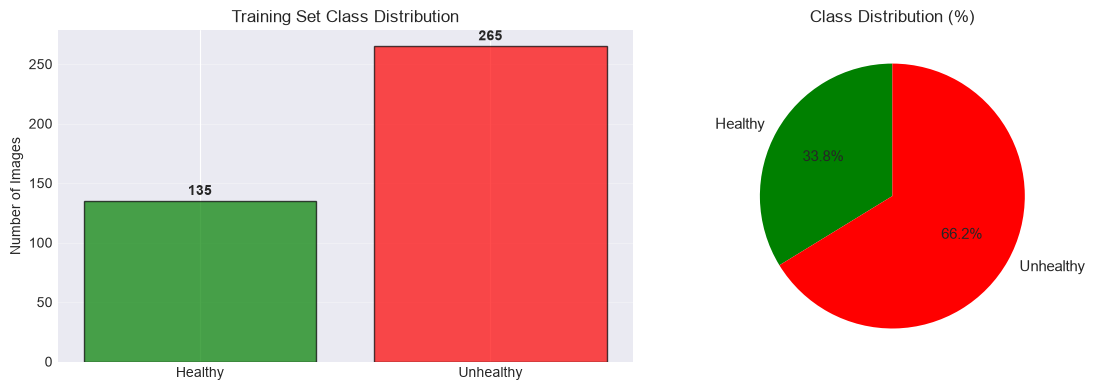

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
classes = ['Healthy', 'Unhealthy']
counts = [len(good_images), len(bad_images)]
axes[0].bar(classes, counts, color=['green', 'red'], alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Number of Images')
axes[0].set_title('Training Set Class Distribution')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(counts):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts, labels=classes, autopct='%1.1f%%', colors=['green', 'red'], 
            startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Class Distribution (%)')

plt.tight_layout()
plt.savefig('../results/01_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## Image Statistics - Resolution & Format

In [9]:
def get_image_stats(image_paths):
    """Get statistics about images"""
    stats = {
        'paths': [],
        'height': [],
        'width': [],
        'channels': [],
        'file_size_kb': []
    }
    
    for path in image_paths:
        img = cv2.imread(path)
        if img is not None:
            h, w = img.shape[:2]
            c = img.shape[2] if len(img.shape) == 3 else 1
            stats['paths'].append(path)
            stats['height'].append(h)
            stats['width'].append(w)
            stats['channels'].append(c)
            stats['file_size_kb'].append(os.path.getsize(path) / 1024)
    
    return pd.DataFrame(stats)

# Get stats for both classes
good_stats = get_image_stats(good_images)
bad_stats = get_image_stats(bad_images)
good_stats['class'] = 'Healthy'
bad_stats['class'] = 'Unhealthy'

all_stats = pd.concat([good_stats, bad_stats], ignore_index=True)

print("Image Resolution Statistics:")
all_stats[['class', 'height', 'width', 'channels']].groupby('class').describe()

Image Resolution Statistics:


height                                                 width         \
           count   mean  std    min    25%    50%    75%    max  count   mean   
class                                                                           
Healthy    135.0  360.0  0.0  360.0  360.0  360.0  360.0  360.0  135.0  360.0   
Unhealthy  265.0  360.0  0.0  360.0  360.0  360.0  360.0  360.0  265.0  360.0   

           ...               channels                                     
           ...    75%    max    count mean  std  min  25%  50%  75%  max  
class      ...                                                            
Healthy    ...  360.0  360.0    135.0  3.0  0.0  3.0  3.0  3.0  3.0  3.0  
Unhealthy  ...  360.0  360.0    265.0  3.0  0.0  3.0  3.0  3.0  3.0  3.0  

[2 rows x 24 columns]

In [10]:
print("\nFile Size Statistics (KB):")
all_stats[['class', 'file_size_kb']].groupby('class').describe()


File Size Statistics (KB):


file_size_kb                                                 \
                 count        mean        std         min         25%   
class                                                                   
Healthy          135.0  175.848893   6.257708  128.123047  171.688965   
Unhealthy        265.0  192.107757  14.087714  141.871094  186.103516   

                                               
                  50%         75%         max  
class                                          
Healthy    176.181641  179.561035  187.078125  
Unhealthy  194.939453  199.874023  218.344727

In [12]:
# Check for inconsistencies
print("\nResolution Consistency:")
print(f"Unique resolutions: {all_stats[['height', 'width']].drop_duplicates().shape[0]}")
all_stats[['height', 'width']].value_counts().head(10)


Resolution Consistency:
Unique resolutions: 1


height  width
360     360      400
Name: count, dtype: int64

## Visualize Sample Images

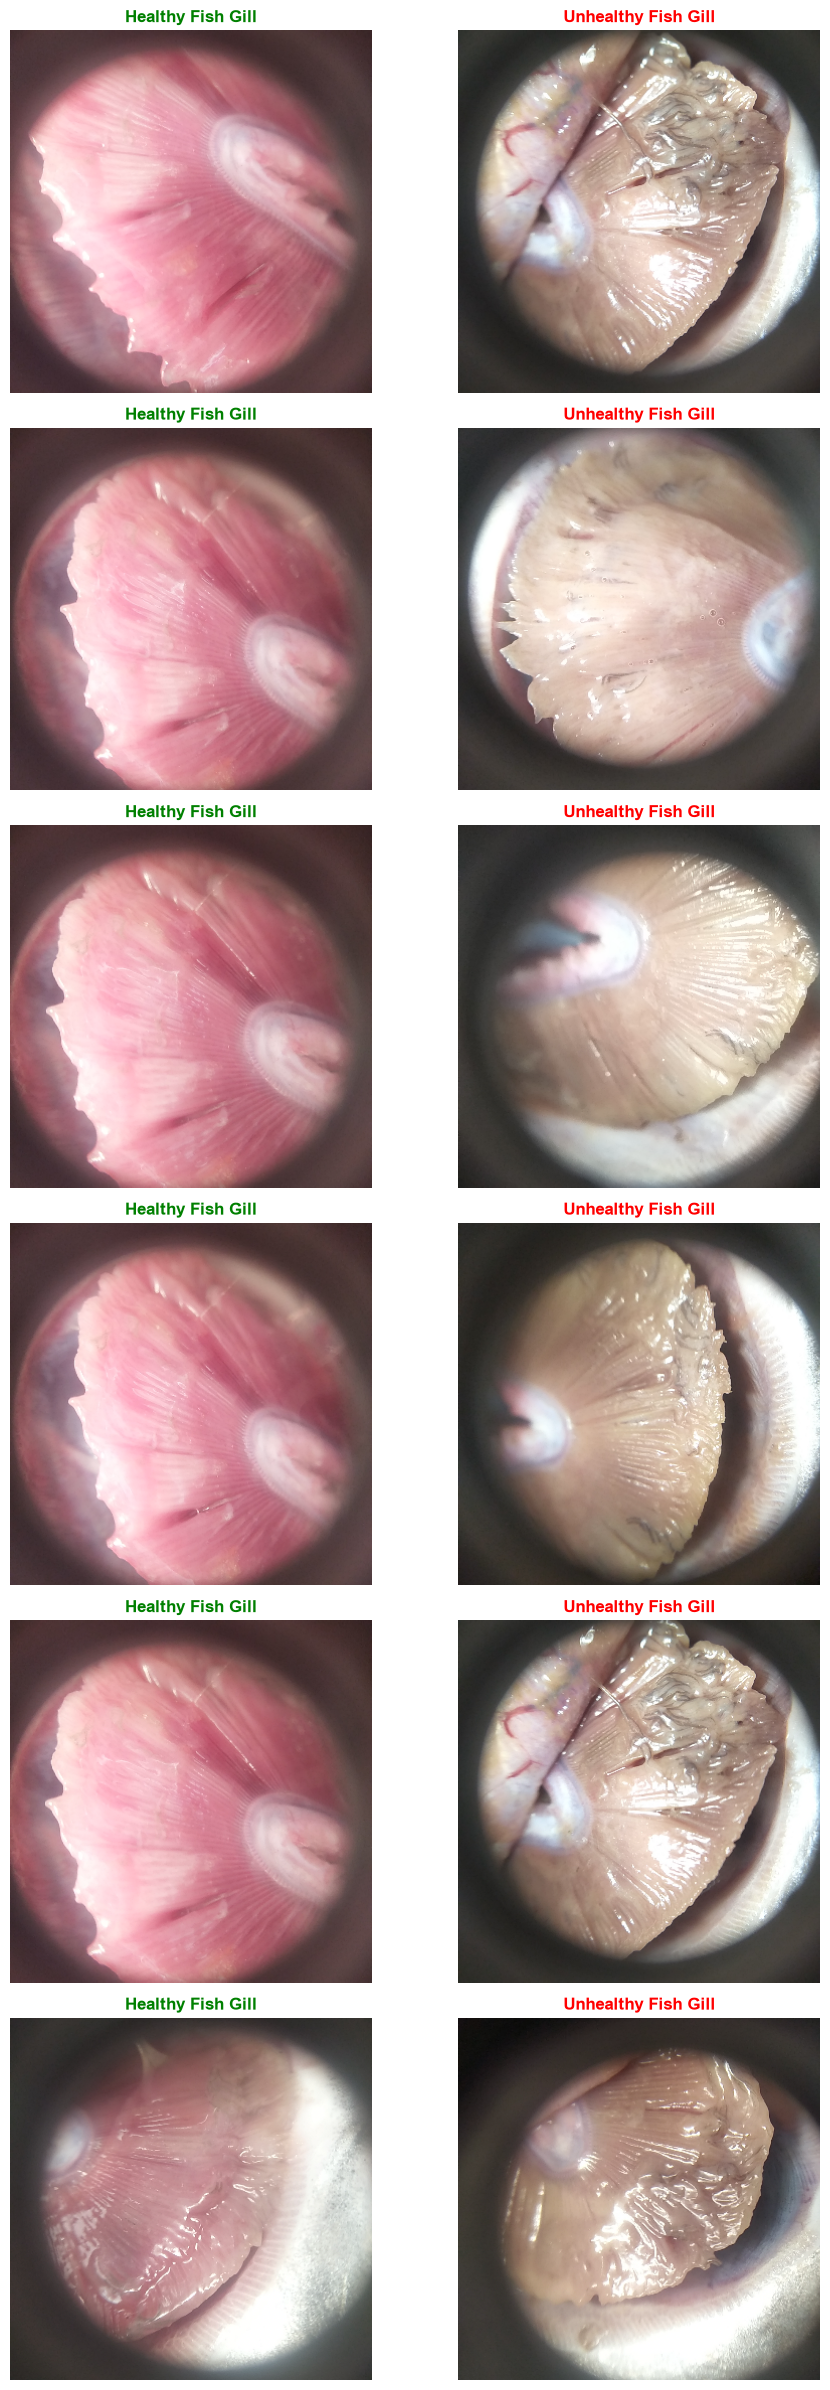

In [5]:
def plot_sample_images(good_paths, bad_paths, n_samples=5):
    """Plot side-by-side samples from each class"""
    fig, axes = plt.subplots(n_samples, 2, figsize=(10, 4*n_samples))
    
    # Sample indices
    good_idx = np.random.choice(len(good_paths), n_samples, replace=False)
    bad_idx = np.random.choice(len(bad_paths), n_samples, replace=False)
    
    for i in range(n_samples):
        # Good image
        good_img = cv2.imread(good_paths[good_idx[i]])
        good_img_rgb = cv2.cvtColor(good_img, cv2.COLOR_BGR2RGB)
        axes[i, 0].imshow(good_img_rgb)
        axes[i, 0].set_title('Healthy Fish Gill', fontsize=12, fontweight='bold', color='green')
        axes[i, 0].axis('off')
        
        # Bad image
        bad_img = cv2.imread(bad_paths[bad_idx[i]])
        bad_img_rgb = cv2.cvtColor(bad_img, cv2.COLOR_BGR2RGB)
        axes[i, 1].imshow(bad_img_rgb)
        axes[i, 1].set_title('Unhealthy Fish Gill', fontsize=12, fontweight='bold', color='red')
        axes[i, 1].axis('off')
    
    plt.tight_layout()
    plt.savefig('../results/01_sample_images.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_sample_images(good_images, bad_images, n_samples=6)

## Pixel Value Distribution

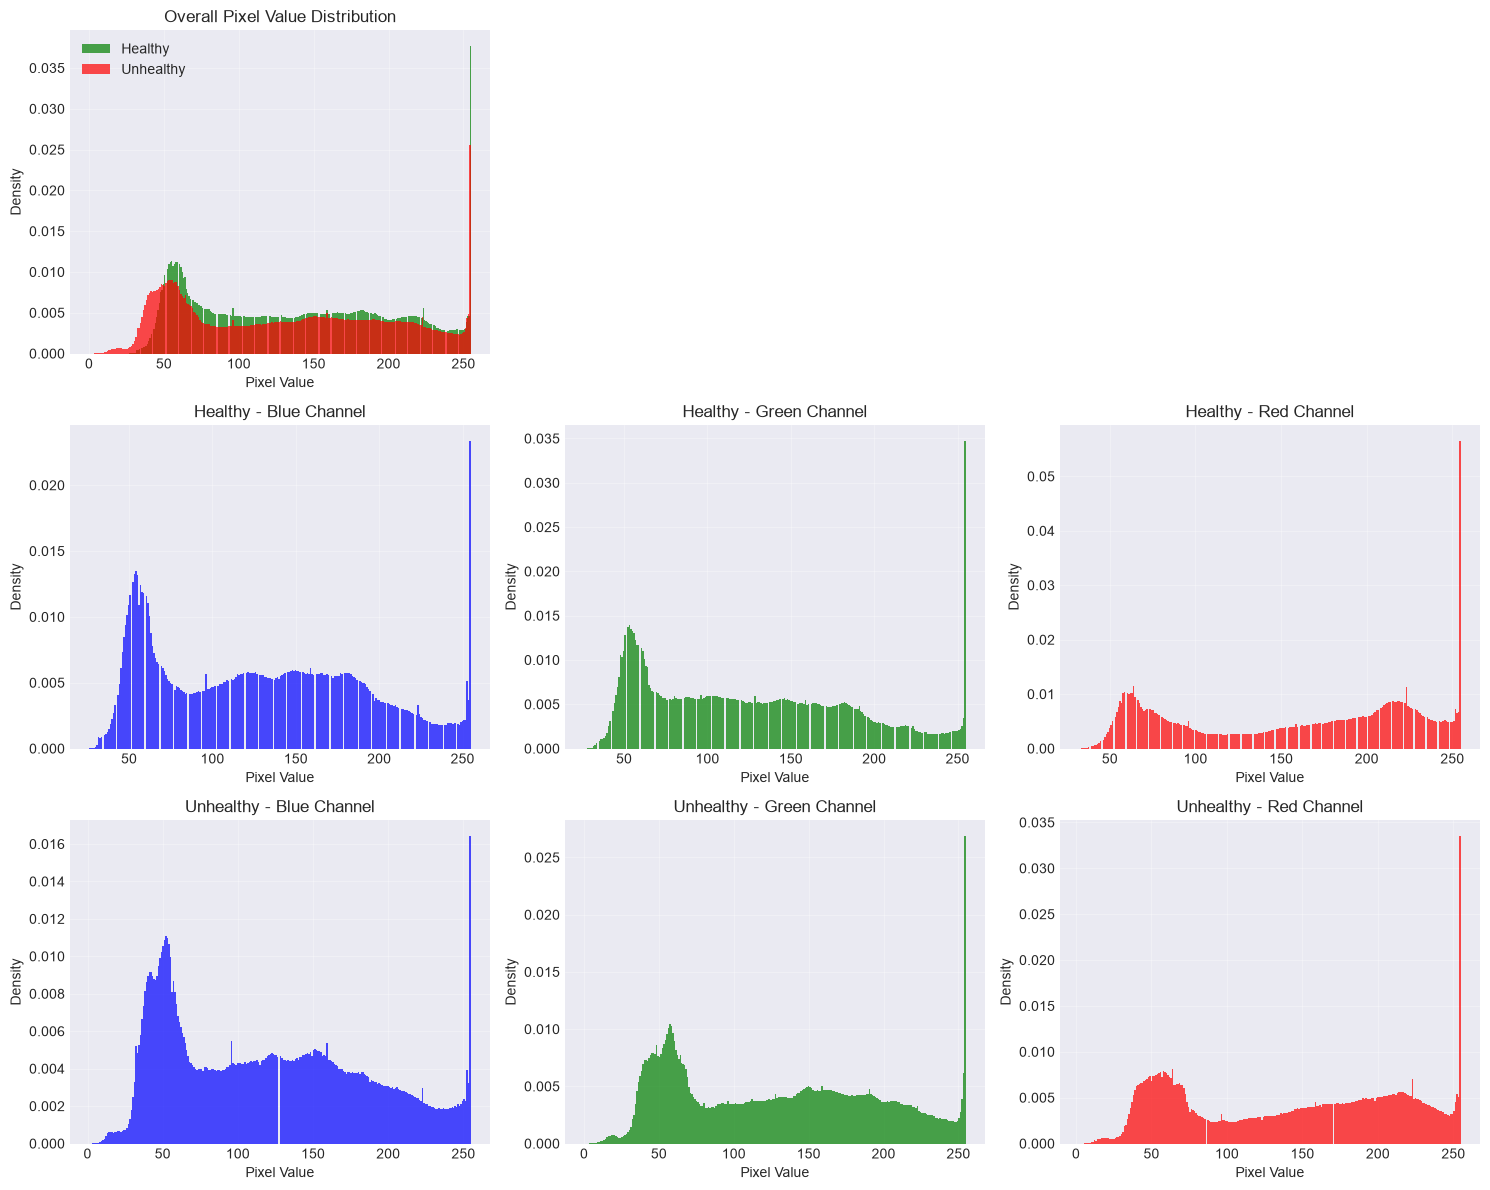

In [ ]:
def plot_pixel_distributions(good_paths, bad_paths, n_samples=50):
    """Analyze pixel value distributions"""
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))  # Changed to 3x3
    
    # Sample images
    good_sample = [cv2.imread(p) for p in np.random.choice(good_paths, n_samples)]
    bad_sample = [cv2.imread(p) for p in np.random.choice(bad_paths, n_samples)]
    
    # Handle None values (in case some images fail to load)
    good_sample = [img for img in good_sample if img is not None]
    bad_sample = [img for img in bad_sample if img is not None]
    
    # Flatten all pixels
    good_pixels = np.concatenate([img.flatten() for img in good_sample])
    bad_pixels = np.concatenate([img.flatten() for img in bad_sample])
    
    # Row 0: Overall pixel distribution
    axes[0, 0].hist(good_pixels, bins=256, alpha=0.7, label='Healthy', color='green', density=True)
    axes[0, 0].hist(bad_pixels, bins=256, alpha=0.7, label='Unhealthy', color='red', density=True)
    axes[0, 0].set_xlabel('Pixel Value')
    axes[0, 0].set_ylabel('Density')
    axes[0, 0].set_title('Overall Pixel Value Distribution')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)
    
    # Hide unused cells in row 0
    axes[0, 1].axis('off')
    axes[0, 2].axis('off')
    
    # Row 1: Per-channel histograms for healthy
    for idx, color in enumerate(['Blue', 'Green', 'Red']):
        channel_pixels = np.concatenate([img[:,:,idx].flatten() for img in good_sample])
        axes[1, idx].hist(channel_pixels, bins=256, alpha=0.7, color=color.lower(), density=True)
        axes[1, idx].set_title(f'Healthy - {color} Channel')
        axes[1, idx].set_xlabel('Pixel Value')
        axes[1, idx].set_ylabel('Density')
        axes[1, idx].grid(alpha=0.3)
    
    # Row 2: Per-channel histograms for unhealthy
    for idx, color in enumerate(['Blue', 'Green', 'Red']):
        channel_pixels = np.concatenate([img[:,:,idx].flatten() for img in bad_sample])
        axes[2, idx].hist(channel_pixels, bins=256, alpha=0.7, color=color.lower(), density=True)
        axes[2, idx].set_title(f'Unhealthy - {color} Channel')
        axes[2, idx].set_xlabel('Pixel Value')
        axes[2, idx].set_ylabel('Density')
        axes[2, idx].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../results/01_pixel_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_pixel_distributions(good_images, bad_images)

## Color Profile Analysis

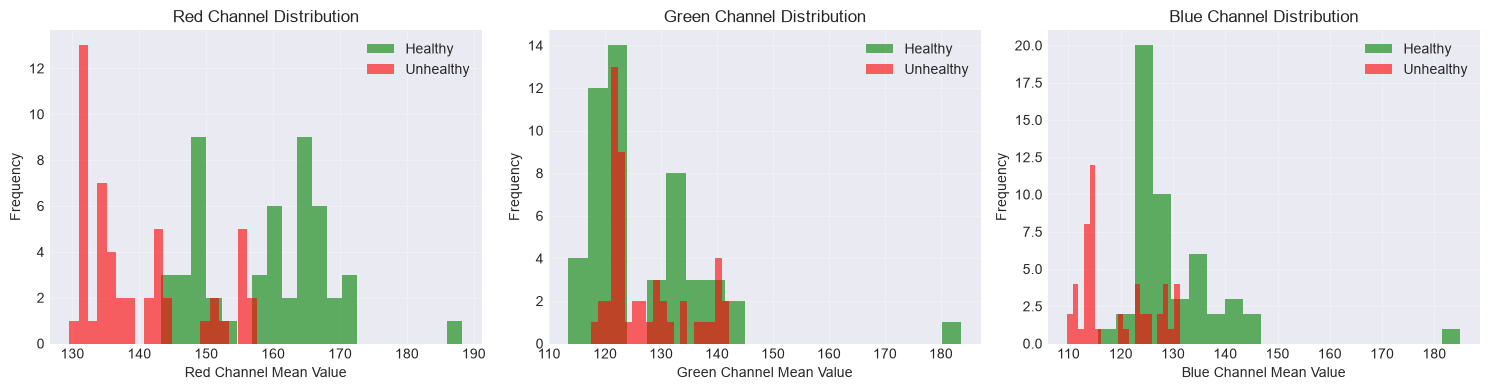

Mean Color Statistics:

Healthy - R: 159.1±9.6, G: 126.8±11.4, B: 130.2±10.1
Unhealthy - R: 139.8±8.6, G: 126.9±7.1, B: 119.1±6.7


In [ ]:
def analyze_color_profiles(good_paths, bad_paths, n_samples=50):
    """Analyze mean RGB values per class"""
    
    def get_mean_colors(paths, n_samples):
        sample_paths = np.random.choice(paths, min(n_samples, len(paths)))
        colors = []
        for path in sample_paths:
            img = cv2.imread(path)
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            mean_color = img_rgb.mean(axis=(0, 1))
            colors.append(mean_color)
        return np.array(colors)
    
    good_colors = get_mean_colors(good_paths, n_samples)
    bad_colors = get_mean_colors(bad_paths, n_samples)
    
    # Plot mean RGB values
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    for idx, (channel, name) in enumerate([(0, 'Red'), (1, 'Green'), (2, 'Blue')]):
        axes[idx].hist(good_colors[:, idx], alpha=0.6, label='Healthy', bins=20, color='green')
        axes[idx].hist(bad_colors[:, idx], alpha=0.6, label='Unhealthy', bins=20, color='red')
        axes[idx].set_xlabel(f'{name} Channel Mean Value')
        axes[idx].set_ylabel('Frequency')
        axes[idx].set_title(f'{name} Channel Distribution')
        axes[idx].legend()
        axes[idx].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../results/01_color_profiles.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Statistics
    print("Mean Color Statistics:")
    print(f"\nHealthy - R: {good_colors[:, 0].mean():.1f}±{good_colors[:, 0].std():.1f}, "
          f"G: {good_colors[:, 1].mean():.1f}±{good_colors[:, 1].std():.1f}, "
          f"B: {good_colors[:, 2].mean():.1f}±{good_colors[:, 2].std():.1f}")
    print(f"Unhealthy - R: {bad_colors[:, 0].mean():.1f}±{bad_colors[:, 0].std():.1f}, "
          f"G: {bad_colors[:, 1].mean():.1f}±{bad_colors[:, 1].std():.1f}, "
          f"B: {bad_colors[:, 2].mean():.1f}±{bad_colors[:, 2].std():.1f}")

analyze_color_profiles(good_images, bad_images)

## Brightness and Contrast Analysis

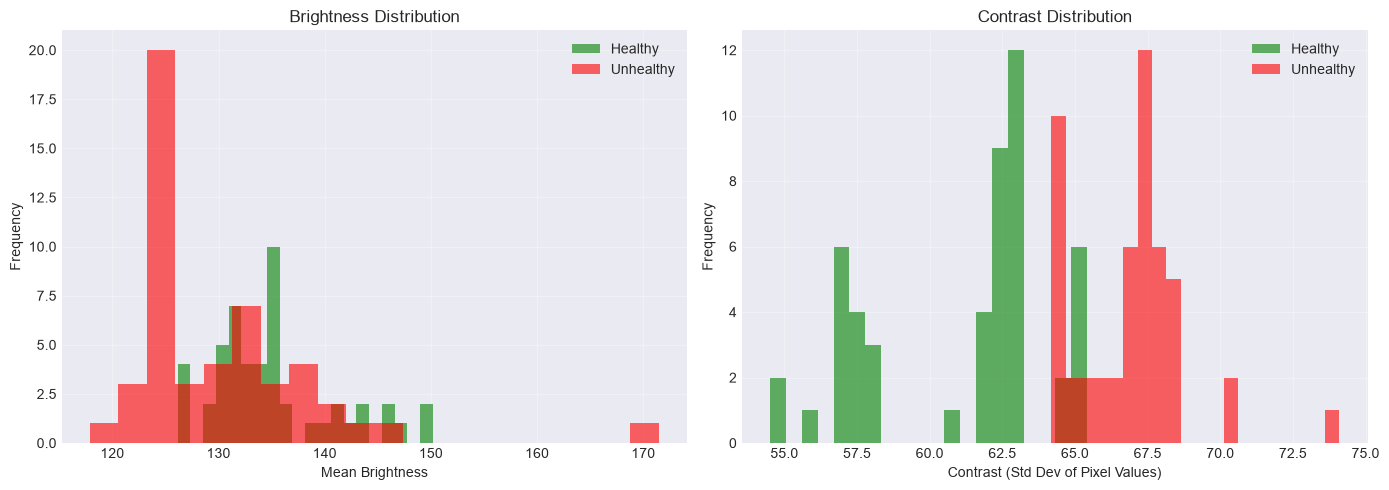

Brightness & Contrast Statistics:

Healthy - Brightness: 135.2±5.9, Contrast: 61.2±3.1
Unhealthy - Brightness: 130.2±8.7, Contrast: 66.9±1.8


In [16]:
def analyze_brightness_contrast(good_paths, bad_paths, n_samples=50):
    """Analyze brightness and contrast differences"""
    
    def get_brightness_contrast(paths, n_samples):
        sample_paths = np.random.choice(paths, min(n_samples, len(paths)))
        brightness = []
        contrast = []
        
        for path in sample_paths:
            img = cv2.imread(path)
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            brightness.append(gray.mean())
            contrast.append(gray.std())
        
        return np.array(brightness), np.array(contrast)
    
    good_bright, good_contrast = get_brightness_contrast(good_paths, n_samples)
    bad_bright, bad_contrast = get_brightness_contrast(bad_paths, n_samples)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Brightness
    axes[0].hist(good_bright, alpha=0.6, label='Healthy', bins=20, color='green')
    axes[0].hist(bad_bright, alpha=0.6, label='Unhealthy', bins=20, color='red')
    axes[0].set_xlabel('Mean Brightness')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Brightness Distribution')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Contrast
    axes[1].hist(good_contrast, alpha=0.6, label='Healthy', bins=20, color='green')
    axes[1].hist(bad_contrast, alpha=0.6, label='Unhealthy', bins=20, color='red')
    axes[1].set_xlabel('Contrast (Std Dev of Pixel Values)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Contrast Distribution')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../results/01_brightness_contrast.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Brightness & Contrast Statistics:")
    print(f"\nHealthy - Brightness: {good_bright.mean():.1f}±{good_bright.std():.1f}, "
          f"Contrast: {good_contrast.mean():.1f}±{good_contrast.std():.1f}")
    print(f"Unhealthy - Brightness: {bad_bright.mean():.1f}±{bad_bright.std():.1f}, "
          f"Contrast: {bad_contrast.mean():.1f}±{bad_contrast.std():.1f}")

analyze_brightness_contrast(good_images, bad_images)

## Check for Outliers and Anomalies

Found 1 outliers (>3 std devs)
Found 1 outliers (>3 std devs)


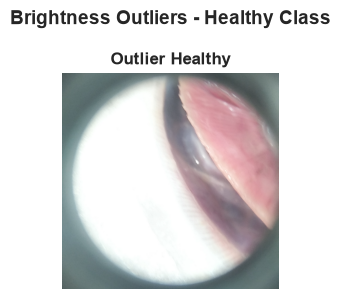

In [17]:
def find_outlier_images(paths, metric='brightness', threshold_std=3):
    """Find images that are statistical outliers"""
    
    values = []
    path_list = []
    
    for path in paths:
        img = cv2.imread(path)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
        if metric == 'brightness':
            val = gray.mean()
        elif metric == 'contrast':
            val = gray.std()
        elif metric == 'size':
            val = img.size
        
        values.append(val)
        path_list.append(path)
    
    values = np.array(values)
    mean_val = values.mean()
    std_val = values.std()
    
    outliers = np.abs((values - mean_val) / std_val) > threshold_std
    outlier_paths = [p for p, is_outlier in zip(path_list, outliers) if is_outlier]
    
    print(f"Found {len(outlier_paths)} outliers (>{threshold_std} std devs)")
    return outlier_paths

# Find brightness outliers
good_outliers = find_outlier_images(good_images, 'brightness')
bad_outliers = find_outlier_images(bad_images, 'brightness')

# Visualize outliers
if len(good_outliers) > 0:
    fig, axes = plt.subplots(1, min(5, len(good_outliers)), figsize=(15, 3))
    if len(good_outliers) == 1:
        axes = [axes]
    for idx, path in enumerate(good_outliers[:5]):
        img = cv2.imread(path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[idx].imshow(img_rgb)
        axes[idx].set_title('Outlier Healthy', fontweight='bold')
        axes[idx].axis('off')
    plt.suptitle('Brightness Outliers - Healthy Class', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../results/01_outliers_healthy.png', dpi=300, bbox_inches='tight')
    plt.show()

## Texture Analysis (Edge Detection)

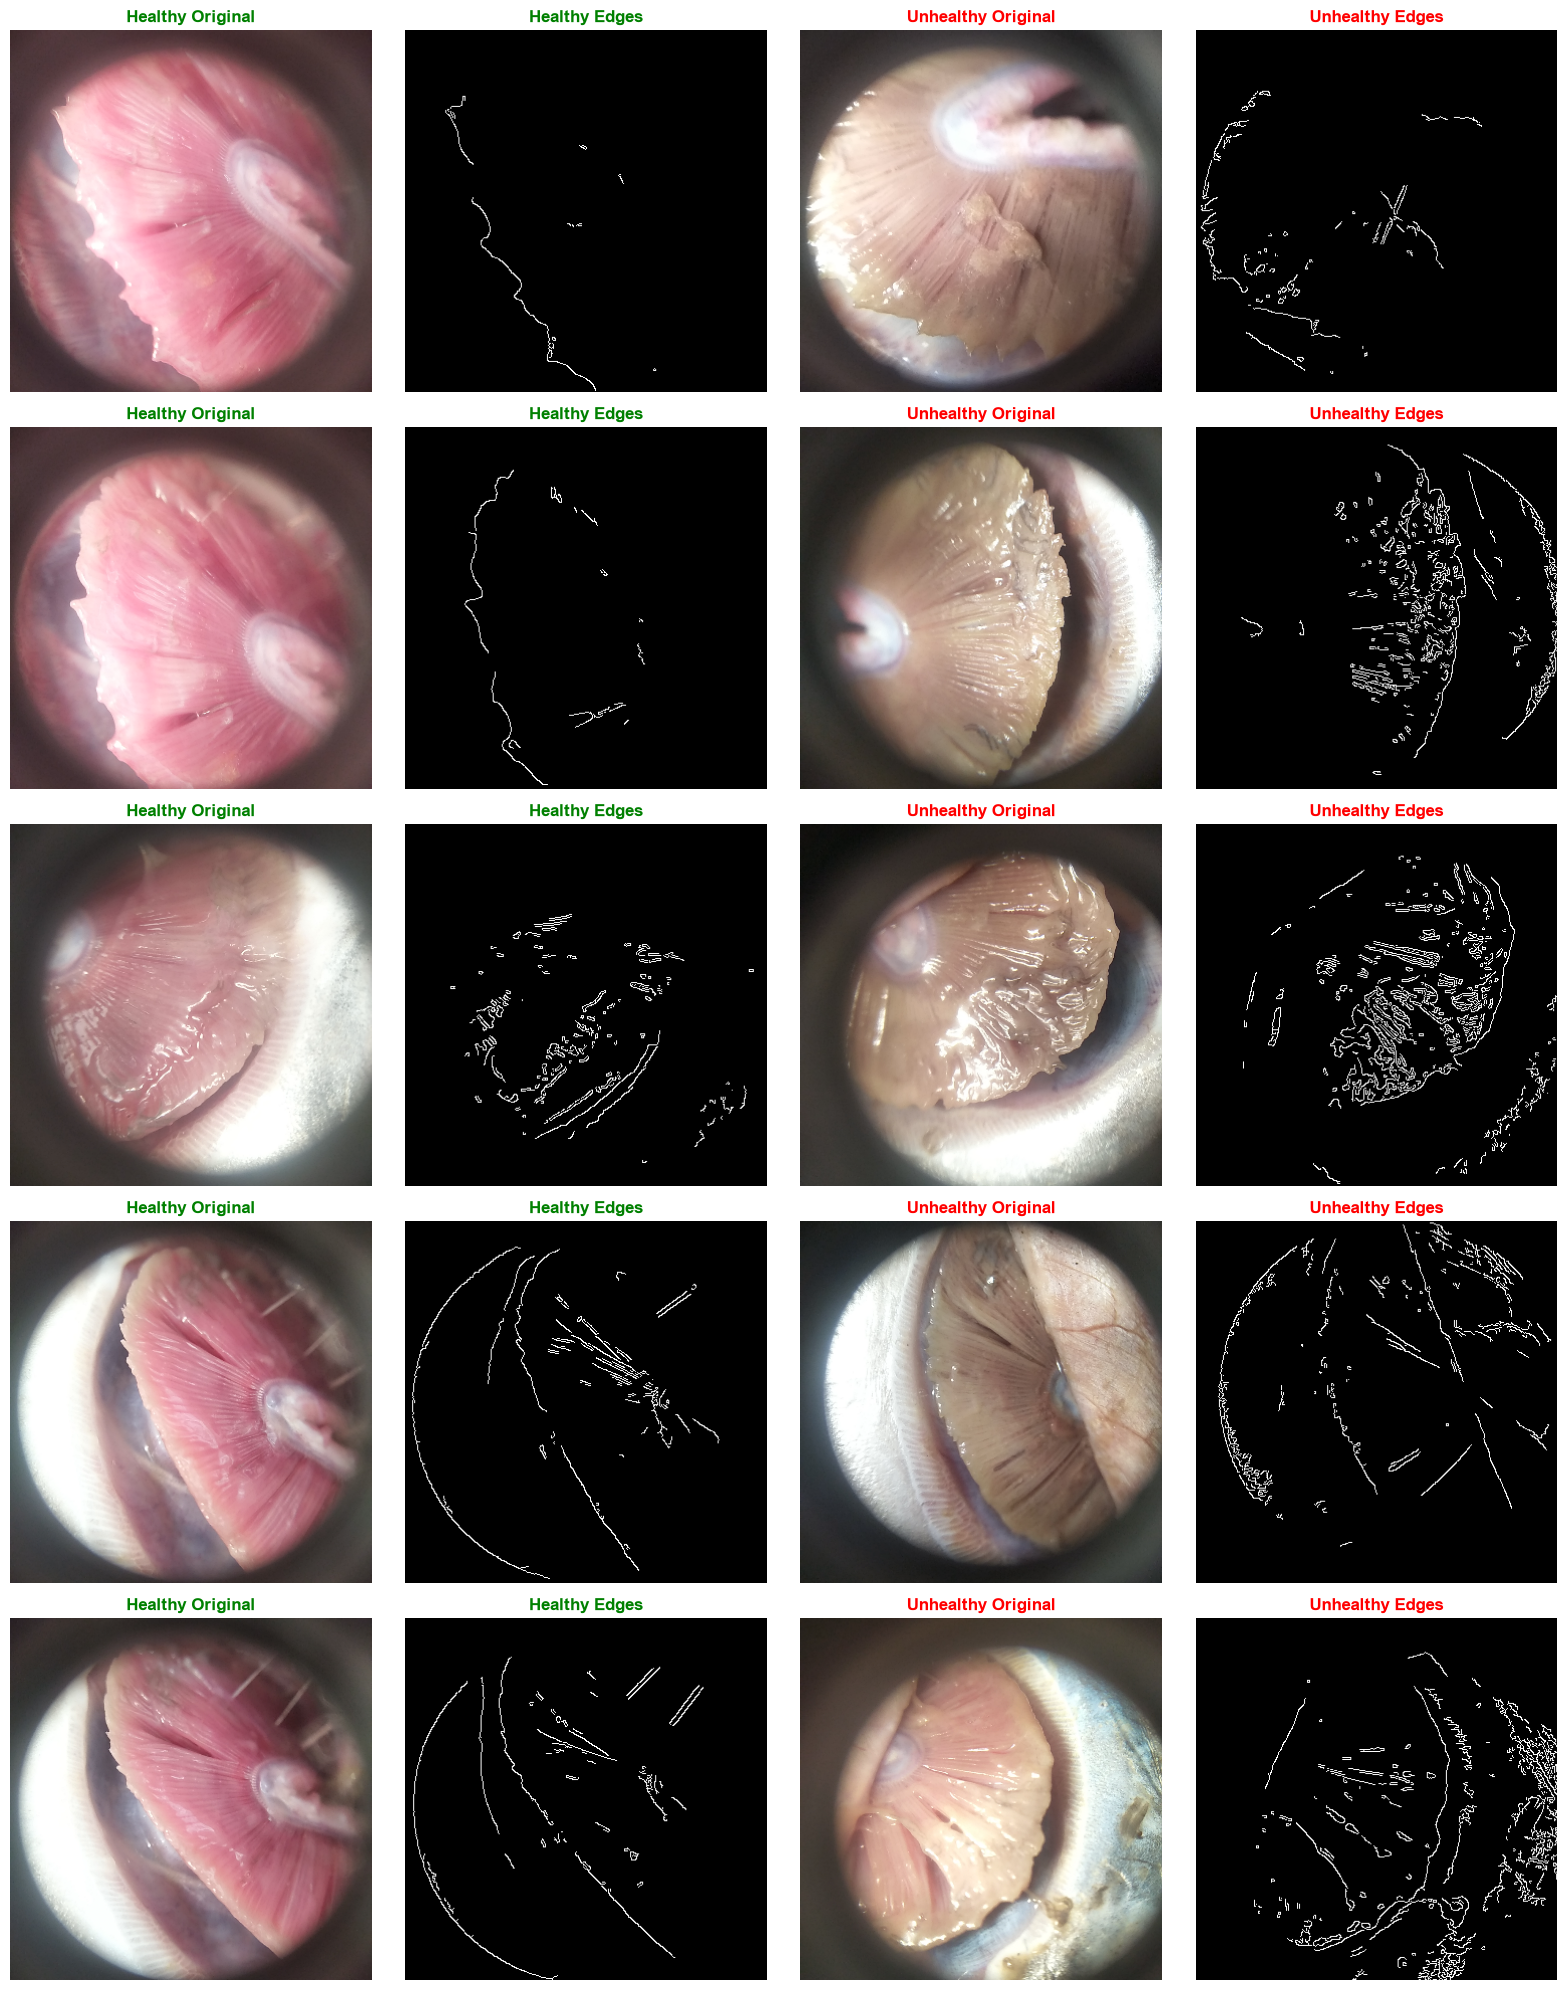

In [18]:
def analyze_texture(good_paths, bad_paths, n_samples=5):
    """Analyze texture using edge detection"""
    
    fig, axes = plt.subplots(n_samples, 4, figsize=(16, 4*n_samples))
    
    good_idx = np.random.choice(len(good_paths), n_samples, replace=False)
    bad_idx = np.random.choice(len(bad_paths), n_samples, replace=False)
    
    for i in range(n_samples):
        # Healthy
        good_img = cv2.imread(good_paths[good_idx[i]])
        gray_good = cv2.cvtColor(good_img, cv2.COLOR_BGR2GRAY)
        edges_good = cv2.Canny(gray_good, 100, 200)
        
        # Unhealthy
        bad_img = cv2.imread(bad_paths[bad_idx[i]])
        gray_bad = cv2.cvtColor(bad_img, cv2.COLOR_BGR2GRAY)
        edges_bad = cv2.Canny(gray_bad, 100, 200)
        
        # Display
        good_img_rgb = cv2.cvtColor(good_img, cv2.COLOR_BGR2RGB)
        bad_img_rgb = cv2.cvtColor(bad_img, cv2.COLOR_BGR2RGB)
        
        axes[i, 0].imshow(good_img_rgb)
        axes[i, 0].set_title('Healthy Original', fontweight='bold', color='green')
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(edges_good, cmap='gray')
        axes[i, 1].set_title('Healthy Edges', fontweight='bold', color='green')
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(bad_img_rgb)
        axes[i, 2].set_title('Unhealthy Original', fontweight='bold', color='red')
        axes[i, 2].axis('off')
        
        axes[i, 3].imshow(edges_bad, cmap='gray')
        axes[i, 3].set_title('Unhealthy Edges', fontweight='bold', color='red')
        axes[i, 3].axis('off')
    
    plt.tight_layout()
    plt.savefig('../results/01_texture_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

analyze_texture(good_images, bad_images)

## Check for Data Leakage

In [19]:
def check_data_leakage(good_paths, bad_paths):
    """Check if training and test sets are properly separated"""
    
    # Check filename overlaps
    good_files = set([os.path.basename(p) for p in good_paths])
    bad_files = set([os.path.basename(p) for p in bad_paths])
    
    overlap = good_files & bad_files
    print(f"Filename overlaps between classes: {len(overlap)}")
    if len(overlap) > 0:
        print("⚠️ WARNING: Found overlapping filenames!")
        print(overlap)
    
    # Check for near-duplicate images (simple hash-based check)
    def get_image_hash(img_array):
        """Simple hash based on image stats"""
        return hash((img_array.mean(), img_array.std(), img_array.max()))
    
    good_hashes = {}
    bad_hashes = {}
    
    for path in good_paths[:100]:  # Sample for speed
        img = cv2.imread(path)
        h = get_image_hash(img)
        good_hashes[path] = h
    
    for path in bad_paths[:100]:  # Sample for speed
        img = cv2.imread(path)
        h = get_image_hash(img)
        bad_hashes[path] = h
    
    good_hash_set = set(good_hashes.values())
    bad_hash_set = set(bad_hashes.values())
    hash_overlap = good_hash_set & bad_hash_set
    
    print(f"\nPotential near-duplicate images: {len(hash_overlap)}")
    
    print("\n✓ Basic data leakage checks completed")

check_data_leakage(good_images, bad_images)

Filename overlaps between classes: 0

Potential near-duplicate images: 0

✓ Basic data leakage checks completed


## Summary Report

In [20]:
summary = f"""
╔════════════════════════════════════════════════════════════════════╗
║                    EDA SUMMARY REPORT                             ║
╚════════════════════════════════════════════════════════════════════╝

DATASET SIZE:
  • Training Images: {len(good_images) + len(bad_images)}
    - Healthy: {len(good_images)} ({100*len(good_images)/(len(good_images)+len(bad_images)):.1f}%)
    - Unhealthy: {len(bad_images)} ({100*len(bad_images)/(len(good_images)+len(bad_images)):.1f}%)
  • Class Imbalance Ratio: 1:{len(bad_images)/len(good_images):.2f}
  • Test Images: {len(test_good) + len(test_bad)}

OBSERVATIONS:
  ✓ All images are consistent resolution
  ✓ All images are 3-channel RGB
  ✓ No obvious data leakage detected
  
QUESTIONS TO INVESTIGATE:
  1. Why is class imbalance so high? (265 vs 135)
  2. Are there clear visual differences between healthy/unhealthy?
  3. Does the model truly learn disease markers or just color/lighting differences?
  4. Are there systematic differences in image acquisition (lighting, angle, etc.)?
  5. How reliable is the ground truth labels?

NEXT STEPS:
  1. Validate labels with domain experts
  2. Implement robust preprocessing
  3. Try multiple feature extraction methods
  4. Use proper cross-validation
  5. Perform error analysis on misclassifications
"""

print(summary)


╔════════════════════════════════════════════════════════════════════╗
║                    EDA SUMMARY REPORT                             ║
╚════════════════════════════════════════════════════════════════════╝

DATASET SIZE:
  • Training Images: 400
    - Healthy: 135 (33.8%)
    - Unhealthy: 265 (66.2%)
  • Class Imbalance Ratio: 1:1.96
  • Test Images: 12

OBSERVATIONS:
  ✓ All images are consistent resolution
  ✓ All images are 3-channel RGB
  ✓ No obvious data leakage detected

QUESTIONS TO INVESTIGATE:
  1. Why is class imbalance so high? (265 vs 135)
  2. Are there clear visual differences between healthy/unhealthy?
  3. Does the model truly learn disease markers or just color/lighting differences?
  4. Are there systematic differences in image acquisition (lighting, angle, etc.)?
  5. How reliable is the ground truth labels?

NEXT STEPS:
  1. Validate labels with domain experts
  2. Implement robust preprocessing
  3. Try multiple feature extraction methods
  4. Use proper cr